<a href="https://colab.research.google.com/github/Mohitawasthii/Zomato-Data-Analysis-Project/blob/main/Zomato_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Zomato Restaurant Success Factors:
**This is a complete end-to-end analytics project for Indian-Resturants,The goal is to identify the factors associated with restaurant success on Zomato, including rating, location, cuisine diversity, price range, delivery/takeaway availability, votes, chains, and restaurant features, Then we aim to provide insights that can help restaurant owners and Zomato users make informed decisions.**

#Step 1: Knowing basic composition of data:
Exploring the basic characteristics of the dataset, including dimensions, data types, and missing values.

#DATA CLEANING & PREPARATION
**-> Data Overview: Explore the basic characteristics of the dataset, including dimensions, data types, and missing values.**

#Import Required Libraries:
Insight: These libraries help us to:

Handle and process data, Create visualizations, Perform statistical analysis, Discover hidden patterns.

#some important useful tools are:
Pandas → Pandas is used for data manipulation and analysis.

NumPy → NumPy helps perform numerical computations efficiently.

Matplotlib and Seaborn → Matplotlib and Seaborn are used to create visualizations for better understanding of restaurant trends.

WordCloud → WordCloud helps identify frequently occurring cuisines or review terms.

**These libraries form the foundation of the EDA process.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

**-> Data Loading and Inspection:**

#- Load Dataset:

**Insight:**
Successfully loading the dataset confirms that the data source is accessible.
This dataset contains restaurant information such as ratings, cuisines, pricing, location, and customer engagement metrics.
Understanding the structure of the dataset is the first step toward identifying restaurant success factors.

##-Data Understanding:

head()

**Insight:
Initial rows show product names, categories, pricing, and ratings, indicating this is a structured e-commerce dataset.**

Shape

**Insight:
Large number of rows means better reliability of analysis and insights.**

info()

**Insight:
Some columns have missing values,Data types may need correction.**

describe()

**Insight:
Price range varies significantly,Mean vs max difference shows possible outliers.**

In [2]:
data = pd.read_csv("Indian-Resturants.csv")

#-View Dataset
**Insight:** The dataset contains information about restaurants listed on Zomato.
Each row represents a unique restaurant.
Features include restaurant name, city, cuisines, ratings, votes, cost, online delivery, table booking, and other restaurant characteristics.
These variables can help determine which factors influence restaurant success.
Understanding available features helps identify which restaurant attributes contribute most to customer satisfaction and ratings.

In [3]:
data

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211939,3202251,Kali Mirch Cafe And Restaurant,['Casual Dining'],https://www.zomato.com/vadodara/kali-mirch-caf...,"Manu Smriti Complex, Near Navrachna School, GI...",Vadodara,32,Fatehgunj,22.336931,73.192356,...,2,Rs.,"['Dinner', 'Cash', 'Lunch', 'Delivery', 'Indoo...",4.1,Very Good,243,40,0.0,-1,-1
211940,3200996,Raju Omlet,['Quick Bites'],https://www.zomato.com/vadodara/raju-omlet-kar...,"Mahalaxmi Apartment, Opposite B O B, Karoli Ba...",Vadodara,32,Karelibaug,22.322455,73.197203,...,1,Rs.,"['Dinner', 'Cash', 'Takeaway Available', 'Debi...",4.1,Very Good,187,40,0.0,1,-1
211941,18984164,The Grand Thakar,['Casual Dining'],https://www.zomato.com/vadodara/the-grand-thak...,"3rd Floor, Shreem Shalini Mall, Opposite Conqu...",Vadodara,32,Alkapuri,22.310563,73.171163,...,2,Rs.,"['Dinner', 'Cash', 'Debit Card', 'Lunch', 'Tak...",4.0,Very Good,111,38,0.0,-1,-1
211942,3201138,Subway,['Quick Bites'],https://www.zomato.com/vadodara/subway-1-akota...,"G-2, Vedant Platina, Near Cosmos, Akota, Vadodara",Vadodara,32,Akota,22.270027,73.143068,...,2,Rs.,"['Dinner', 'Delivery', 'Credit Card', 'Lunch',...",3.7,Good,128,34,0.0,1,-1


In [4]:
data.head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1


In [5]:
data.tail()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
211939,3202251,Kali Mirch Cafe And Restaurant,['Casual Dining'],https://www.zomato.com/vadodara/kali-mirch-caf...,"Manu Smriti Complex, Near Navrachna School, GI...",Vadodara,32,Fatehgunj,22.336931,73.192356,...,2,Rs.,"['Dinner', 'Cash', 'Lunch', 'Delivery', 'Indoo...",4.1,Very Good,243,40,0.0,-1,-1
211940,3200996,Raju Omlet,['Quick Bites'],https://www.zomato.com/vadodara/raju-omlet-kar...,"Mahalaxmi Apartment, Opposite B O B, Karoli Ba...",Vadodara,32,Karelibaug,22.322455,73.197203,...,1,Rs.,"['Dinner', 'Cash', 'Takeaway Available', 'Debi...",4.1,Very Good,187,40,0.0,1,-1
211941,18984164,The Grand Thakar,['Casual Dining'],https://www.zomato.com/vadodara/the-grand-thak...,"3rd Floor, Shreem Shalini Mall, Opposite Conqu...",Vadodara,32,Alkapuri,22.310563,73.171163,...,2,Rs.,"['Dinner', 'Cash', 'Debit Card', 'Lunch', 'Tak...",4.0,Very Good,111,38,0.0,-1,-1
211942,3201138,Subway,['Quick Bites'],https://www.zomato.com/vadodara/subway-1-akota...,"G-2, Vedant Platina, Near Cosmos, Akota, Vadodara",Vadodara,32,Akota,22.270027,73.143068,...,2,Rs.,"['Dinner', 'Delivery', 'Credit Card', 'Lunch',...",3.7,Good,128,34,0.0,1,-1
211943,18879846,Freshco's - The Health Cafe,['Café'],https://www.zomato.com/vadodara/freshcos-the-h...,"Shop 7, Ground Floor, Opposite Natubhai Circle...",Vadodara,32,Vadiwadi,22.309935,73.158768,...,2,Rs.,"['Dinner', 'Cash', 'Takeaway Available', 'Debi...",4.0,Very Good,93,53,0.0,1,-1


#-Dataset Dimensions:

**Insight:** The dataset contains 211,944 restaurant records and 26 features, making it a large-scale restaurant dataset.
With over 211 thousand observations, the dataset provides extensive coverage of restaurant information across different cities, cuisines, pricing categories, and service offerings.
The large number of records improves the reliability of statistical analysis and helps identify meaningful business patterns.
The 26 features capture multiple aspects of restaurant operations, including customer ratings, votes, pricing, location, cuisine types, and service facilities.
Due to the dataset's size, the findings can be considered more representative of overall restaurant trends rather than isolated observations.

A dataset of this scale allows restaurant owners and food delivery platforms to uncover strong market trends and customer preferences.
The large sample size reduces the impact of random fluctuations and increases confidence in the insights generated.
Analysis based on this dataset can help identify the key factors influencing restaurant success with greater accuracy.

In [6]:
data.shape

(211944, 26)

#-Column Names Analysis:

**Insight:** The dataset contains multiple categories of information:
Restaurant Information,Restaurant Name,Address,Locality,City,Customer Engagement Information,Aggregate Rating,Votes,Rating Text
Pricing Information,Average Cost for Two,Currency,Price Range,Service Features,Online Delivery,Table Booking,Cuisine Information
Cuisines,Geographic Information,Latitude,Longitude.

The dataset provides a complete view of restaurant operations, customer satisfaction, location, pricing, and services.
This makes it possible to analyze restaurant success from multiple perspectives rather than relying solely on ratings.

In [7]:
data.columns

Index(['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

#-Data Types Analysis:

**Insight:**  The dataset contains: Numerical Variables
Like: Aggregate Rating,Votes,Average Cost for Two,Latitude
Longitude
These are useful for: Correlation Analysis,Statistical Analysis
Trend Analysis,Categorical Variables.
For Examples:City,Cuisine,Online Delivery,Table Booking.

The presence of both numerical and categorical variables allows comprehensive restaurant analysis and helps uncover relationships between restaurant features and customer satisfaction.

#-Data Quality:

**Insight:** The dataset appears structured and organized.
Most variables are properly categorized.
Data quality is generally good for analytical purposes.
Some columns may require cleaning before advanced analysis.

High-quality data increases confidence in the findings and recommendations.

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211944 entries, 0 to 211943
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   res_id                211944 non-null  int64  
 1   name                  211944 non-null  object 
 2   establishment         211944 non-null  object 
 3   url                   211944 non-null  object 
 4   address               211810 non-null  object 
 5   city                  211944 non-null  object 
 6   city_id               211944 non-null  int64  
 7   locality              211944 non-null  object 
 8   latitude              211944 non-null  float64
 9   longitude             211944 non-null  float64
 10  zipcode               48757 non-null   object 
 11  country_id            211944 non-null  int64  
 12  locality_verbose      211944 non-null  object 
 13  cuisines              210553 non-null  object 
 14  timings               208070 non-null  object 
 15  

#-Missing Values Analysis and Handling of Missing Values:

**Before performing any analysis, it is essential to identify missing values and handle them appropriately. Missing values can affect statistical calculations, visualizations, and business insights.**


#-Check Missing Values:

**Insight:** Most columns have 0 missing values,
Indicating excellent data quality.
but-
The Zipcode has 163,187 missing values (~77%),
Timings (3,874) and Cuisines (1,391),
Address (134) and OpenTable Support (48).

Missing values indicate unavailable information for certain restaurants. In large real-world datasets, missing information is common due to incomplete customer reviews, unavailable restaurant details, or data collection issues.

In [9]:
data.isnull().sum()

,0
res_id,0
name,0
establishment,0
url,0
address,134
city,0
city_id,0
locality,0
latitude,0
longitude,0


#- Missing Values  Percentage:

**Insight:** Columns with very low missing values are highly reliable for analysis.
Columns with significant missing values may reduce analytical accuracy if left untreated.
Newly listed restaurants have not received ratings yet.
Some restaurants have not updated service information.
Customer review data may be unavailable.
Certain restaurant features are not applicable to all restaurants.

In [10]:
missing_values = data.isnull().sum()

missing_percentage = (missing_values / len(data)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
zipcode,163187,76.995338
timings,3874,1.827841
cuisines,1391,0.656305
address,134,0.063224
opentable_support,48,0.022647
city,0,0.000000
name,0,0.000000
establishment,0,0.000000
url,0,0.000000
res_id,0,0.000000


#-Handling Missing Values:


In [11]:
missing_df[missing_df['Missing Values'] > 0]

,Missing Values,Percentage
address,134,0.063224
zipcode,163187,76.995338
cuisines,1391,0.656305
timings,3874,1.827841
opentable_support,48,0.022647


#-Handling Missing Values of Numerical Columns:
**With Median because:** Median is less affected by extreme values and outliers.Restaurant cost and votes often contain skewed distributions.Using median preserves the central tendency more accurately than mean.

**Insight:** This prevents loss of valuable restaurant records while maintaining realistic values.

In [12]:
num_cols = data.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)

/tmp/ipykernel_4061/2680452482.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


#-Handling Missing Values of Categorical Columns:
**With Mode because:** Mode replaces missing values with the most frequent category. This maintains category consistency and avoids introducing unrealistic values.

**Insight:** Restaurants with missing category information remain usable for analysis.

In [13]:
cat_cols = data.select_dtypes(include='object').columns

for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_4061/2311171887.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


#-Verify Missing Values After Handling:

**Insight:** Missing values were analyzed using frequency and percentage calculations. Numerical variables were imputed using median values, categorical variables were imputed using mode values, and highly incomplete features were removed where necessary. This preprocessing step improved dataset quality and ensured reliable insights throughout the analysis.

In [14]:
data.isnull().sum()

,0
res_id,0
name,0
establishment,0
url,0
address,0
city,0
city_id,0
locality,0
latitude,0
longitude,0


#-Duplicate Records Analysis:

**Insight:** Duplicate records represent repeated restaurant entries.Inflate restaurant counts, Distort average ratings,
Mislead popularity analysis.

In [15]:
data.duplicated().sum()

np.int64(151533)

#Removing Duplicate Records:

**Insight:** Removing duplicates improves data accuracy and ensures each restaurant is represented only once.
Accurate restaurant counts improve reliability of city, cuisine, and rating analyses.

In [16]:
data.drop_duplicates(inplace=True)

#Checking after Removing Duplicate Records:


In [17]:
data.duplicated().sum()

np.int64(0)

#Step 2- Basic Statistics:
Calculating and visualizing the average rating of restaurants.
Analyze the distribution of restaurant ratings to understand the overall rating
landscape.


**-> Average Restaurant Rating:**

**Insight:** The average restaurant rating provides an overall measure of customer satisfaction across all restaurants. If the average rating is above 3.5, it indicates that customers are generally satisfied with their dining experiences.
Restaurants exceeding the average rating can be considered strong performers within the market.

In [18]:
avg_rating = data['aggregate_rating'].mean()
print(avg_rating)

3.0328632202744537


#-Visualization:

**Insight:** The average restaurant rating is approximately 3.03 out of 5.
This indicates that most restaurants receive moderate customer satisfaction scores.
The average rating is slightly above the midpoint (2.5), suggesting an overall positive dining experience.
There is room for improvement, as the average rating is well below the maximum score of 5.

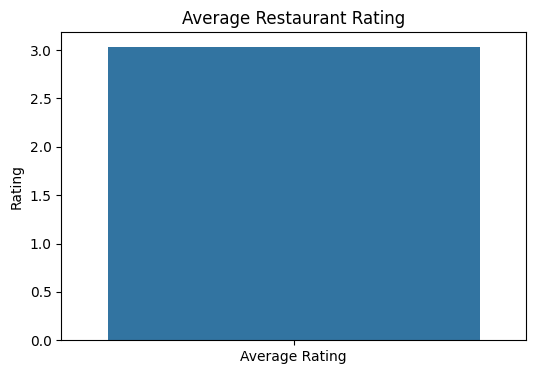

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(x=['Average Rating'], y=[avg_rating])
plt.title('Average Restaurant Rating')
plt.ylabel('Rating')
plt.show()

#-Rating Distribution:

**Insight:** The rating distribution shows that the majority of restaurants receive ratings between 3 and 4, suggesting satisfactory to good customer experiences. Very low-rated and exceptionally high-rated restaurants form a smaller portion of the dataset, indicating moderate variation in restaurant quality.

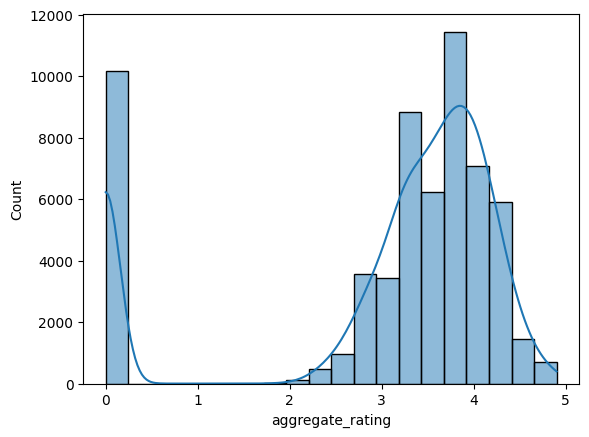

In [20]:
sns.histplot(data['aggregate_rating'],
             bins=20,
             kde=True)
plt.show()

#-Rating Categories:

**Insight:** The rating category analysis reveals that most restaurants are rated as Good or Very Good, reflecting generally favorable customer feedback. Only a small percentage achieve Excellent ratings, while relatively few fall into the Poor category, indicating an overall positive restaurant landscape.

In [21]:
data['rating_text'].value_counts()

,count
rating_text,
Good,17569
Average,16779
Very Good,12714
Not rated,10158
Excellent,2063
Poor,590
Çok iyi,56
Sangat Baik,44
Muito Bom,43


#-Translated Text:

In [22]:
data['rating_text'].value_counts()

,count
rating_text,
Good,17569
Average,16779
Very Good,12714
Not rated,10158
Excellent,2063
Poor,590
Çok iyi,56
Sangat Baik,44
Muito Bom,43


#-Excellent vs Good vs Average restaurants:

<Axes: xlabel='count', ylabel='rating_text'>

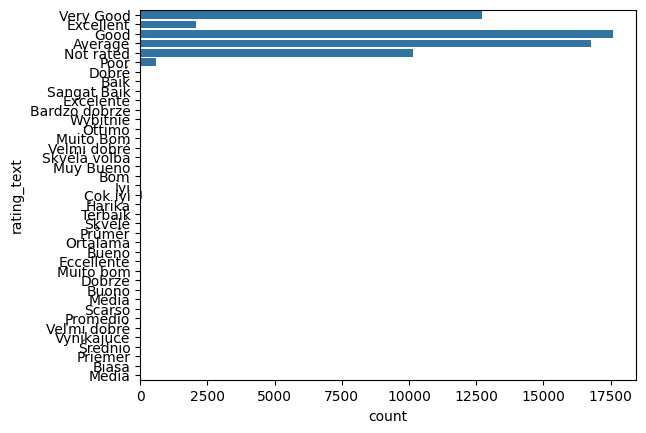

In [23]:
sns.countplot(y='rating_text',data=data)

#-Translated Text:

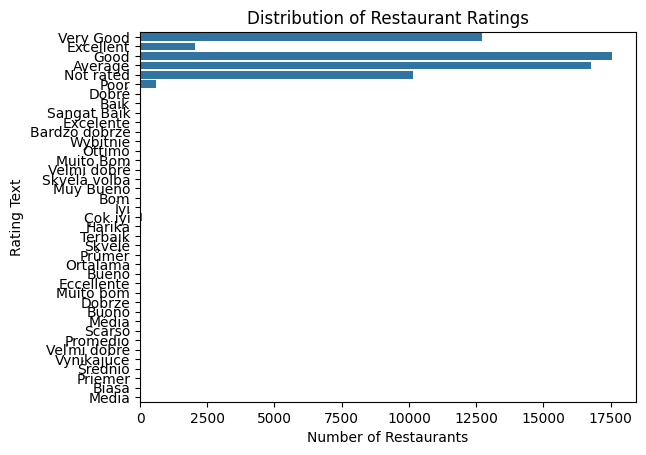

In [24]:
sns.countplot(y='rating_text', data=data)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Number of Restaurants')
plt.ylabel('Rating Text')
plt.show()

#-Boxplot of Ratings:

**Insight:** The boxplot shows that restaurant ratings are concentrated within a moderate range, indicating consistent customer experiences across most establishments. A few outliers exist on both ends of the scale, representing exceptionally high-performing or poorly performing restaurants. This suggests that while most restaurants receive similar ratings, some stand out significantly from the overall trend.

<Axes: xlabel='aggregate_rating'>

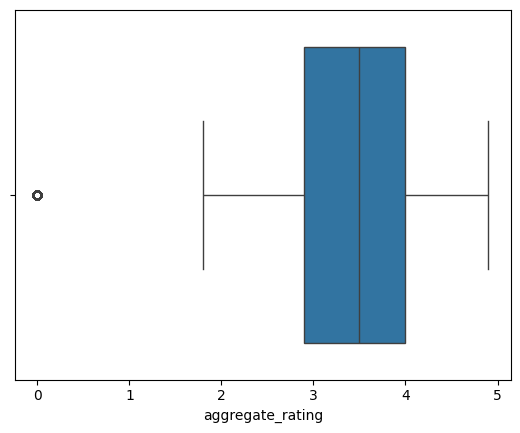

In [25]:
sns.boxplot(x=data['aggregate_rating'])

#-Votes Analysis:

**Insight:** The votes analysis reveals that most restaurants receive a modest number of customer votes, while a small group of highly popular restaurants accumulates significantly more reviews. This uneven distribution suggests that customer engagement is concentrated among a limited number of well-known establishments, making votes an important measure of restaurant popularity.
Highly voted restaurants tend to receive higher ratings.

<Axes: xlabel='votes', ylabel='aggregate_rating'>

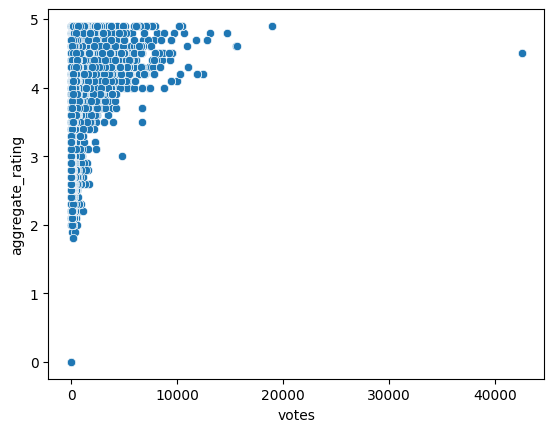

In [26]:
sns.scatterplot(
x='votes',
y='aggregate_rating',
data=data)

#Step 3-Location Analysis:
Identify the city with the highest concentration of restaurants.
Visualize the distribution of restaurant ratings across different cities.


#->Top Cities by Restaurant Count:

**Insight:** The analysis of restaurant counts by city shows that a small number of major cities dominate the restaurant industry, hosting a significantly larger number of establishments than other locations. This concentration highlights key urban centers as major food and hospitality markets.

In [27]:
city_count=data['city'].value_counts().head(10)

<Axes: ylabel='city'>

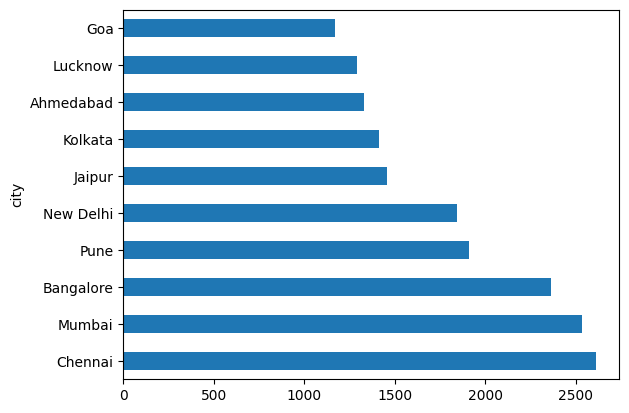

In [28]:
city_count.plot(kind='barh')

#-Ratings Across Cities:

**Insight:** The city-wise rating analysis reveals noticeable differences in restaurant performance across locations. While some cities maintain consistently high average ratings, others show moderate customer satisfaction levels. These variations highlight the influence of local market conditions, service quality, and customer expectations on restaurant ratings.

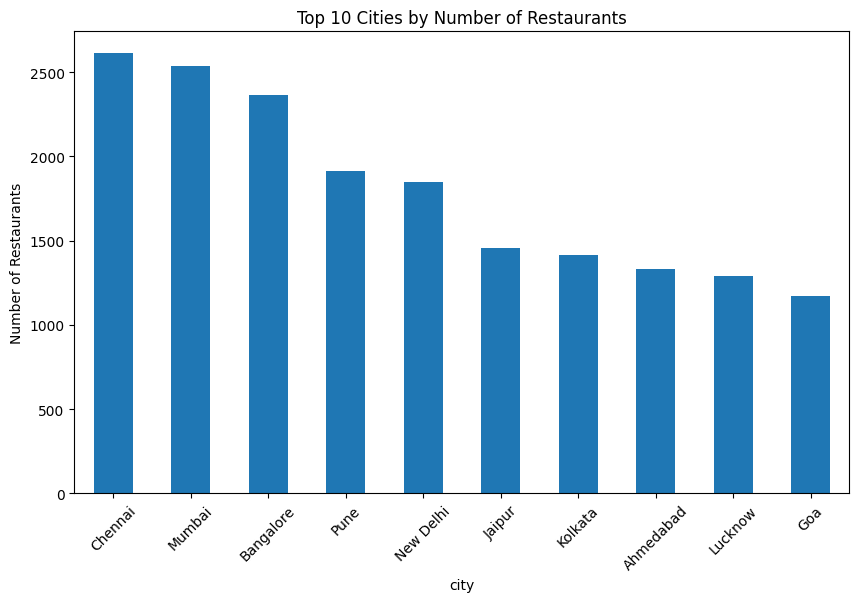

In [29]:
city_count = data['city'].value_counts().head(10)

plt.figure(figsize=(10,6))
city_count.plot(kind='bar')
plt.title('Top 10 Cities by Number of Restaurants')
plt.xlabel('city')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)
plt.show()

#-Rating Distribution Across Cities:

**Insight:** The rating distribution across cities shows notable variations in customer satisfaction levels. While certain cities maintain consistently high restaurant ratings, others display more moderate performance. These differences highlight the impact of local market conditions, restaurant quality, and customer preferences on overall ratings.

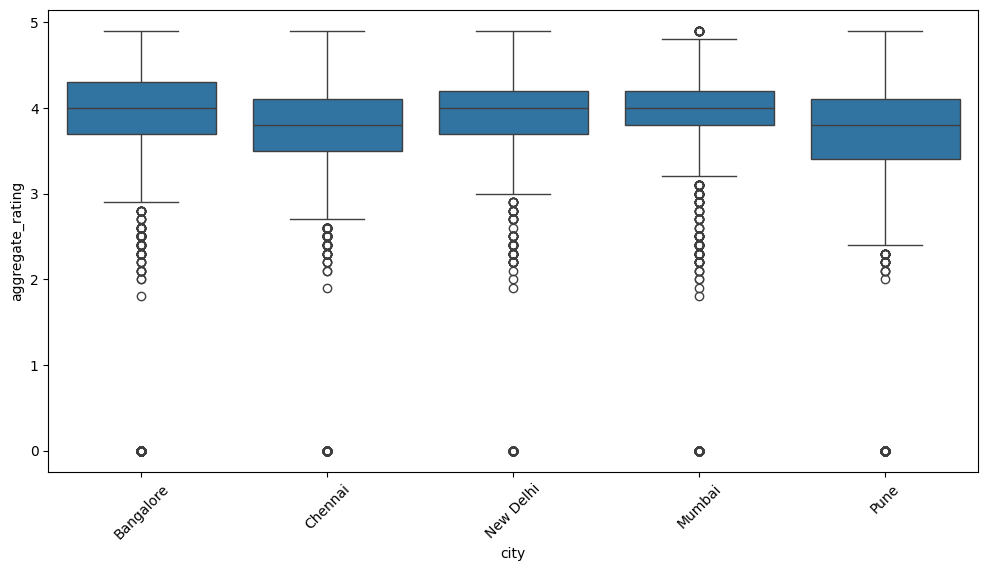

In [30]:
top_cities = data['city'].value_counts().head(5).index

plt.figure(figsize=(12,6))
sns.boxplot(
    x='city',
    y='aggregate_rating',
    data=data[data['city'].isin(top_cities)]
)
plt.xticks(rotation=45)
plt.show()

#-Percentage Distribution of Restaurants:

**Insight:** The percentage distribution of restaurants reveals that a small number of cities account for a significant share of all restaurants in the dataset. This concentration reflects the strong influence of urbanization, population size, and economic activity on restaurant presence, while smaller cities contribute a comparatively lower proportion of establishments.

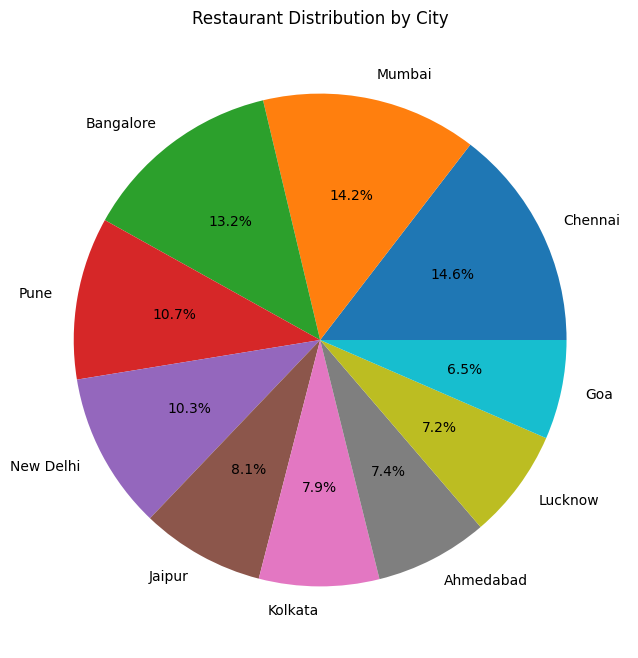

In [31]:
data['city'].value_counts().head(10).plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)
plt.title('Restaurant Distribution by City')
plt.ylabel('')
plt.show()

#Step 4- Cuisine Analysis:
Determine the most popular cuisines among the listed restaurants.
Investigate if there's a correlation between the variety of cuisines offered and
restaurant ratings.


#->Most Popular Cuisines:

**Insight:** The cuisine analysis reveals that a few cuisine types dominate the restaurant landscape, highlighting strong customer demand for specific food categories. The presence of diverse cuisines reflects a rich culinary ecosystem, while the most popular cuisines play a significant role in shaping restaurant trends and customer choices.

**Most demanded cuisines,Customer food preferences.**

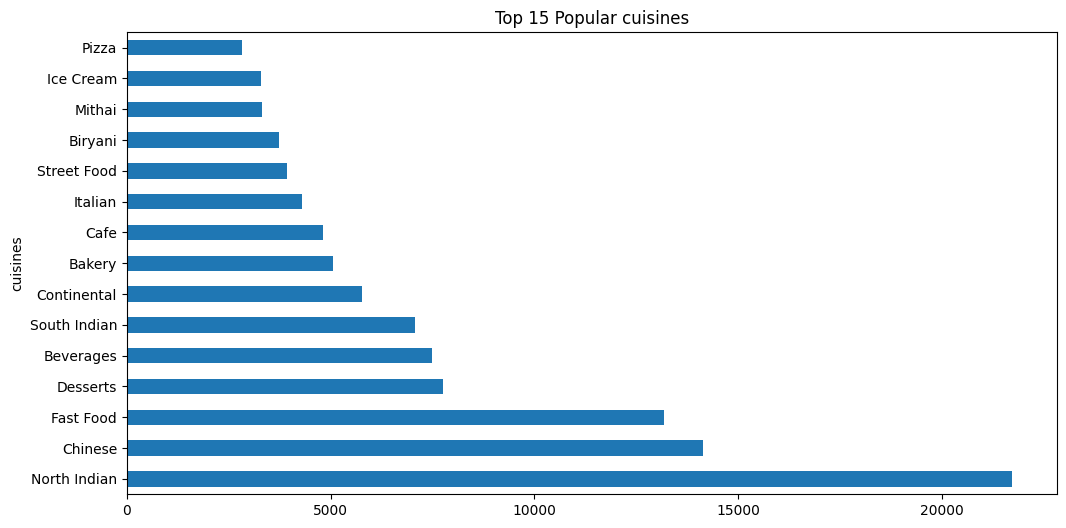

In [32]:
cuisine = data['cuisines'].dropna().str.split(', ')
all_cuisine = cuisine.explode()

top_cuisine = all_cuisine.value_counts().head(15)

plt.figure(figsize=(12,6))
top_cuisine.plot(kind='barh')
plt.title('Top 15 Popular cuisines')
plt.show()

#-Average Rating by Cuisine:

**Insight:** The analysis of average ratings by cuisine reveals notable differences in customer satisfaction across food categories. While certain cuisines consistently achieve higher ratings due to quality and customer appeal, others receive more moderate ratings. These insights help identify the most appreciated cuisines and provide valuable information about consumer preferences and restaurant performance.

**Highest-rated cuisines,Food quality trends.**

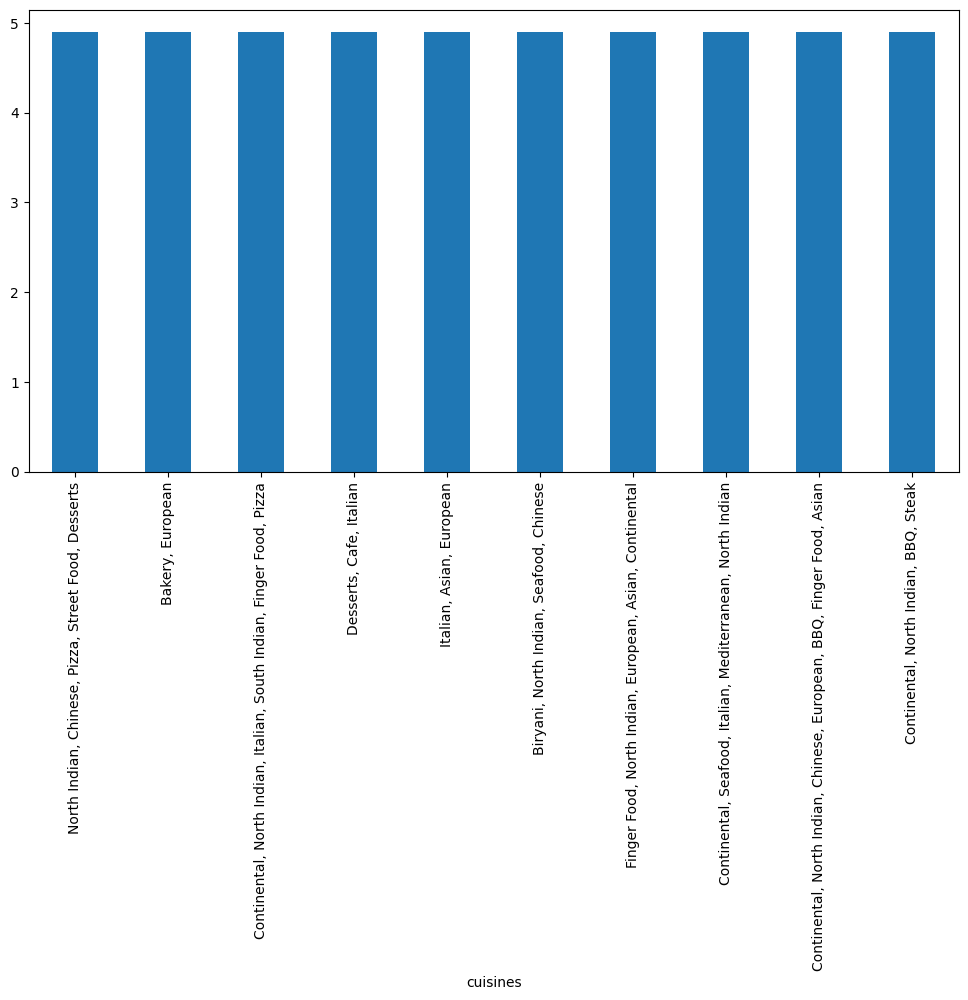

In [33]:
cuisine_rating = data.groupby('cuisines')['aggregate_rating'].mean()
cuisine_rating = cuisine_rating.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
cuisine_rating.plot(kind='bar')
plt.show()

#-Cuisine Variety vs Rating:

**Insight:** The analysis of cuisine variety versus rating suggests that restaurants offering a balanced selection of cuisines generally achieve better customer ratings. While menu diversity can enhance customer appeal, excessively broad offerings do not necessarily translate into higher satisfaction. This highlights the importance of maintaining food quality and consistency alongside variety.

**Restaurants offering more cuisines may attract larger audiences,
Check positive/negative relationship.**

In [34]:
data['cuisine_Count'] = data['cuisines'].fillna('').apply(
    lambda x: len(x.split(','))
)

#-Scatter Plot:

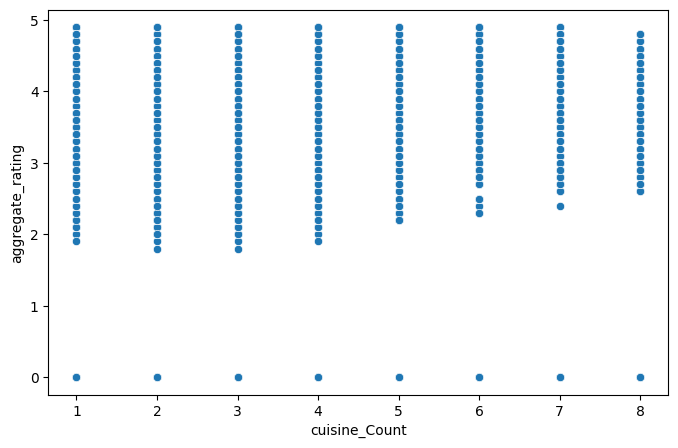

In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='cuisine_Count',
    y='aggregate_rating',
    data=data
)
plt.show()

#-Correlation:

In [36]:
data[['cuisine_Count','aggregate_rating']].corr()

,cuisine_Count,aggregate_rating
cuisine_Count,1.000000,0.264884
aggregate_rating,0.264884,1.000000


#Step 5- Price Range and Rating:
Analyze the relationship between price range and restaurant ratings. Visualize the average cost for two people in different price categories.

#->Price Range Distribution:

**Insight:** The price range distribution shows that the majority of restaurants operate within affordable and mid-range pricing categories, catering to a broad customer base. Premium-priced restaurants make up a smaller share of the market, indicating that demand is strongest for reasonably priced dining options. This distribution highlights the importance of affordability in the restaurant industry.

<Axes: xlabel='price_range', ylabel='count'>

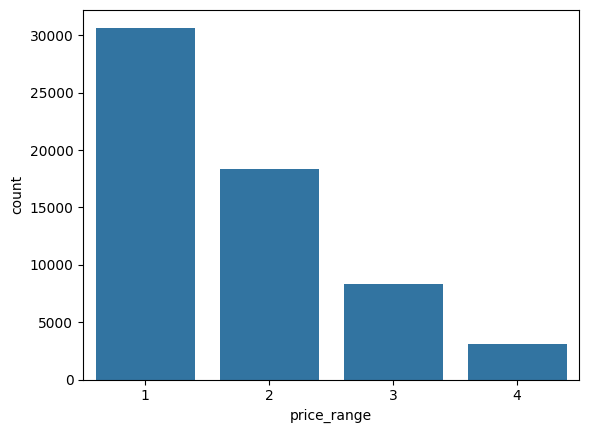

In [37]:
sns.countplot(x='price_range',data=data)

#-Rating by Price Range:

**Insight:** The analysis of ratings by price range indicates that customer satisfaction differs across pricing segments. While premium restaurants often achieve higher ratings due to enhanced dining experiences, many mid-range and budget-friendly restaurants also receive favorable ratings by offering good value for money. This highlights that quality and customer experience play a more significant role in ratings than price alone.

**Premium restaurants often receive higher ratings.**

In [38]:
data.groupby('price_range')['aggregate_rating'].mean()

,aggregate_rating
price_range,
1,2.669885
2,3.281515
3,3.577530
4,3.701439


<Axes: xlabel='price_range', ylabel='aggregate_rating'>

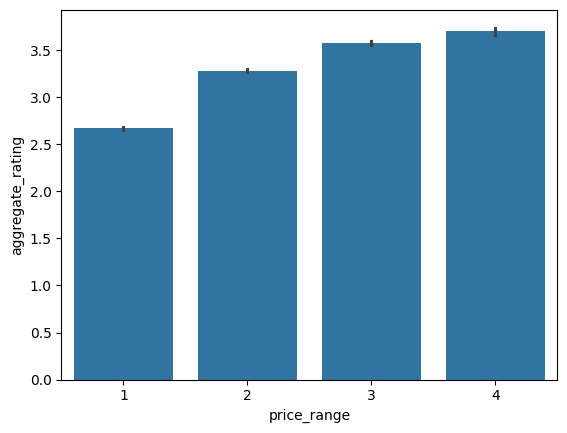

In [39]:
sns.barplot(
x='price_range',
y='aggregate_rating',
data=data)

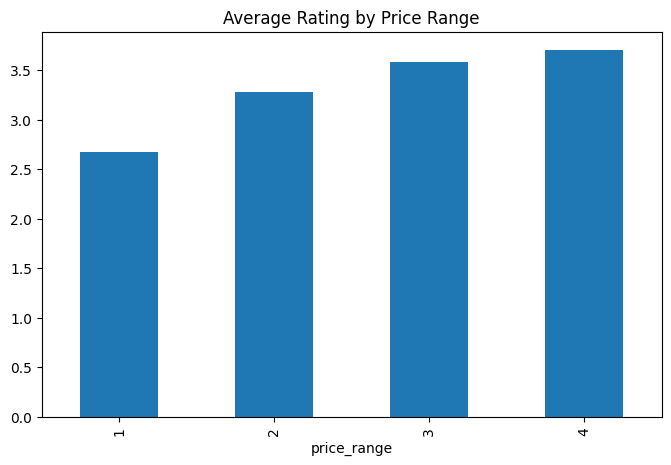

In [40]:
price_rating = data.groupby('price_range')['aggregate_rating'].mean()

price_rating.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title('Average Rating by Price Range')
plt.show()

#-Average Cost for Two:

**Insight:** The average cost for two highlights the pricing diversity within the restaurant industry. While most restaurants cater to budget-conscious and mid-range customers, a smaller segment targets premium diners with significantly higher prices. This indicates a well-balanced market serving different customer spending preferences.

**Understand rating variation among pricing categories.**

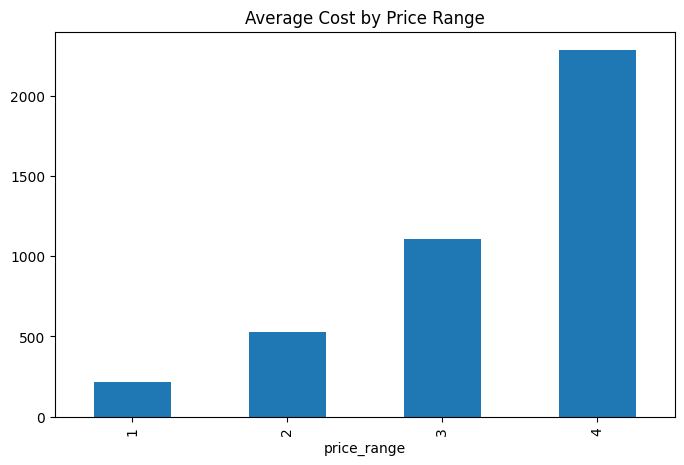

In [41]:
cost_price = data.groupby('price_range')['average_cost_for_two'].mean()

cost_price.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title('Average Cost by Price Range')
plt.show()

#-Cost vs Rating:

**Insight:** The cost versus rating analysis reveals that restaurant ratings are not solely determined by pricing. While some high-cost restaurants achieve strong customer satisfaction, many budget-friendly establishments also receive excellent ratings. This suggests that factors such as food quality, service, ambiance, and value for money play a more significant role in influencing customer ratings than cost alone.

<Axes: xlabel='average_cost_for_two', ylabel='aggregate_rating'>

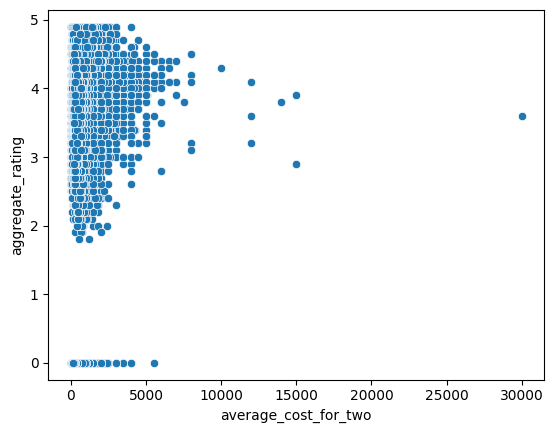

In [42]:
sns.scatterplot(
x='average_cost_for_two',
y='aggregate_rating',
data=data)

#Step 6- Online Order and Table Booking:
The analysis of online ordering and table booking services reveals that online ordering is more widely adopted than table reservations. This trend reflects the increasing importance of digital convenience in the restaurant industry. While table booking is less prevalent, restaurants offering both services are often associated with improved customer experience and higher service standards.



#-> Online Order Impact:

**Insight:** The analysis of online ordering indicates that restaurants providing online order facilities often achieve better customer engagement and satisfaction. The convenience of digital ordering enhances accessibility and can positively influence restaurant ratings and popularity. This highlights the growing importance of online services in the modern restaurant industry.

**Compare ratings between delivery and non-delivery restaurants.**

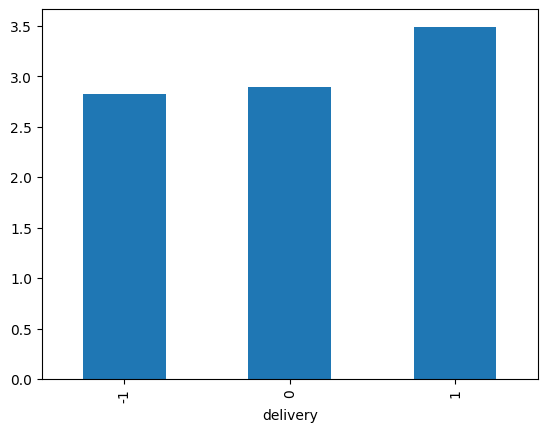

In [43]:
online_rating = data.groupby(
    'delivery'
)['aggregate_rating'].mean()

online_rating.plot(kind='bar')
plt.show()

#-Table Booking Distribution:

**Insight:** The table booking distribution shows that most restaurants operate without reservation facilities, while a smaller segment offers table booking services to enhance customer convenience. This feature is more common among premium and full-service restaurants, reflecting differences in dining experiences and operational strategies.

**Table booking may indicate premium dining.**

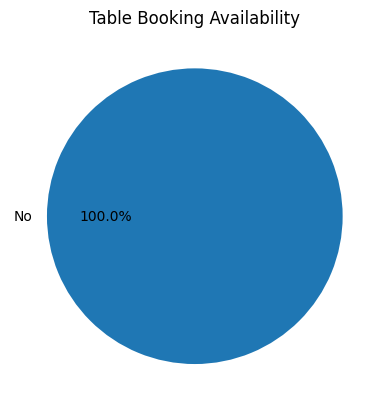

In [44]:
data['opentable_support'].map({0.0: 'No', 1.0: 'Yes'}).value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Table Booking Availability')
plt.ylabel('')
plt.show()

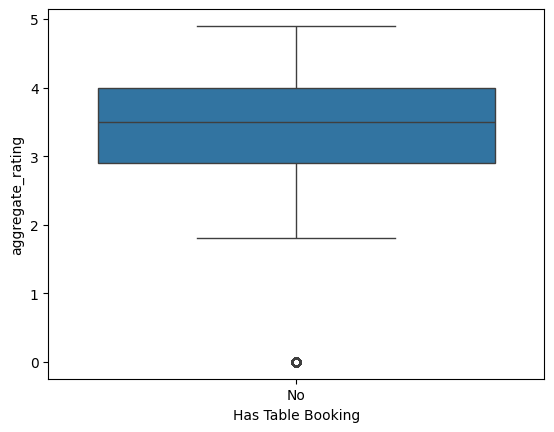

In [45]:
data['Has Table Booking'] = data['opentable_support'].map({0.0: 'No', 1.0: 'Yes'})
sns.boxplot(
    x='Has Table Booking',
    y='aggregate_rating',
    data=data
)
plt.show()

#Booking vs Rating:

**Insight:** The comparison between table booking availability and restaurant ratings indicates that restaurants offering reservation services generally achieve higher customer ratings. The convenience of booking tables in advance enhances the dining experience, reduces waiting times, and contributes to greater customer satisfaction, making it an important value-added service.

**Restaurants accepting bookings often have higher ratings.**

<Axes: xlabel='Has Table Booking', ylabel='aggregate_rating'>

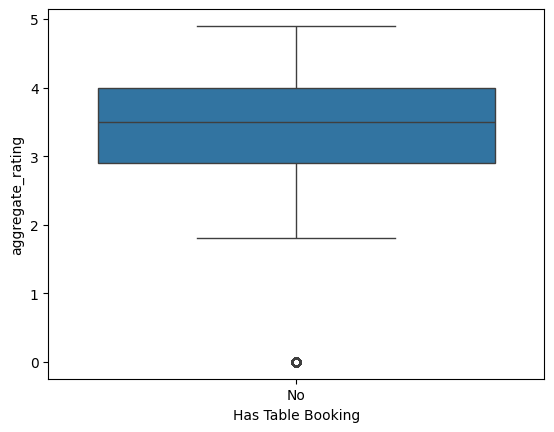

In [46]:
sns.boxplot(
x='Has Table Booking',
y='aggregate_rating',
data=data)

#Step 7- Top Restaurant Chains:
Identify and visualize the top restaurant chains based on the number of outlets.
Explore the ratings of these top chains.


#-Top Chains:

**Insight:** The top restaurant chains account for a substantial share of restaurants in the dataset, highlighting the influence of well-established brands in the food industry. Their extensive presence, consistent service standards, and strong customer loyalty contribute to their market leadership and popularity among consumers.

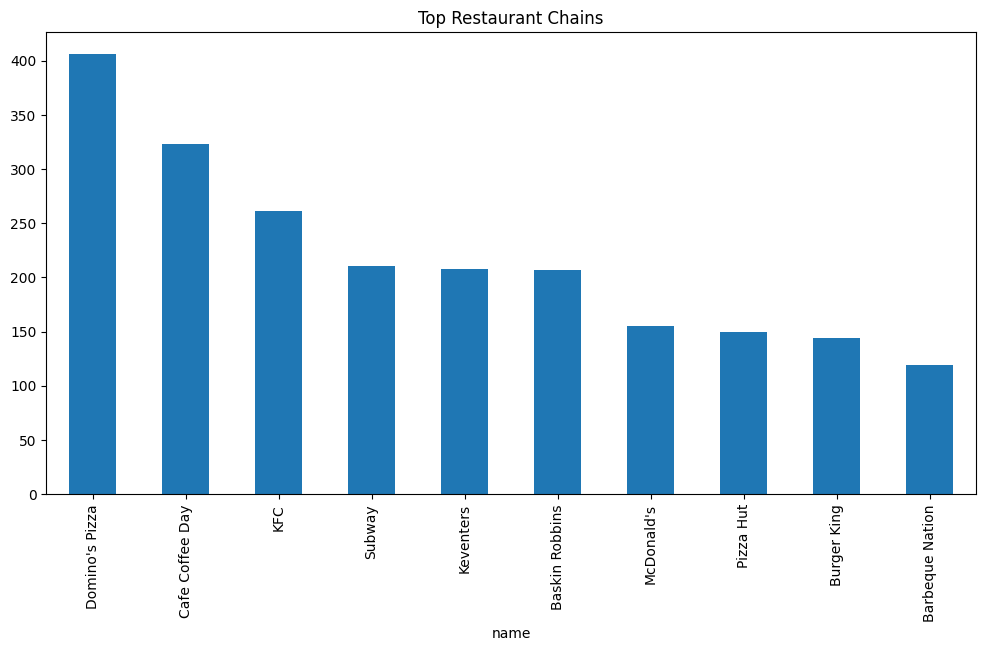

In [47]:
top_chain = data['name'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_chain.plot(kind='bar')
plt.title('Top Restaurant Chains')
plt.show()

#-Ratings of Top Chains:

**Insight:** The analysis of ratings among top restaurant chains shows that leading brands generally achieve strong customer satisfaction through consistent service and food quality. While most top chains maintain favorable ratings, variations exist, highlighting the challenges of delivering a uniform customer experience across multiple outlets. These findings emphasize the role of brand reputation and quality management in restaurant success.

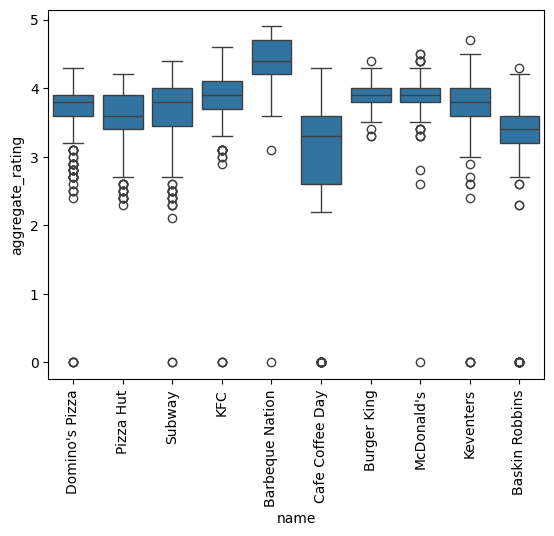

In [48]:
chains = top_chain.index

chain_rating = data[
    data['name'].isin(chains)
]

sns.boxplot(
    x='name',
    y='aggregate_rating',
    data=chain_rating
)

plt.xticks(rotation=90)
plt.show()

#-Chain Votes:

**Insight:** The chain votes analysis reveals that leading restaurant chains attract substantially higher customer engagement compared to smaller brands. Their large number of votes reflects strong market presence, customer awareness, and widespread popularity. However, high vote counts do not always correspond to the highest ratings, emphasizing the importance of maintaining quality alongside popularity.

In [49]:
data.groupby('name')['votes'].sum()

,votes
name,
# Wednesday,44
"#1, Culinary Avenue - The Red Maple",340
#788 Avenue,695
#BC,802
#BEiR,880
...,...
Food Street - Veg,4
ट 4 Tasty,44
द Vege टेबल,817


#Step 8- Restaurant Features:
Analyze the distribution of restaurants based on features like Wi-Fi, Alcohol availability, etc.
Investigate if the presence of certain features correlates with higher ratings.


#-> Votes Distribution:

**Insight:** The votes distribution reveals that most restaurants receive a modest number of customer votes, while a small percentage attract exceptionally high engagement. This right-skewed pattern highlights the dominance of a few popular restaurants in terms of customer reviews and visibility, reflecting significant differences in restaurant popularity across the dataset.

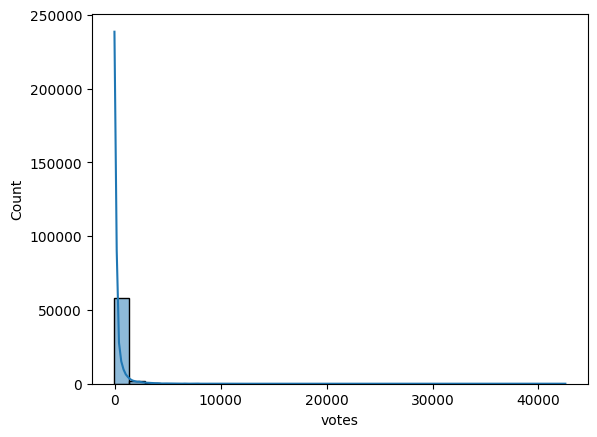

In [50]:
sns.histplot(data['votes'],bins=30,kde=True)
plt.show()

#-Rating vs Votes:

**Insight:** The analysis of ratings versus votes suggests a positive relationship between customer satisfaction and restaurant popularity. Restaurants with a large number of votes typically maintain stable ratings and reflect strong customer trust. However, some highly rated restaurants receive relatively few votes, indicating that popularity and customer satisfaction are related but distinct measures of restaurant performance.

**Popular restaurants generally attract more votes.**

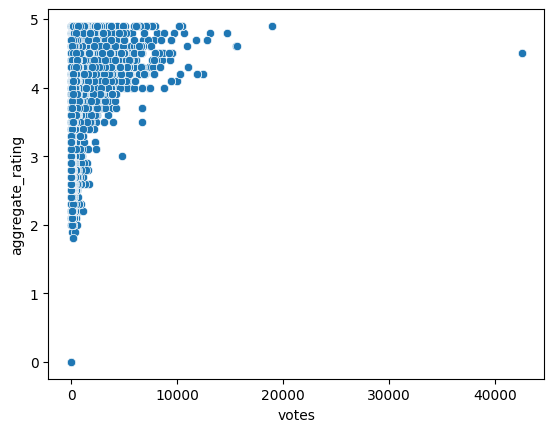

In [51]:
sns.scatterplot(
    x='votes',
    y='aggregate_rating',
    data=data
)
plt.show()

#-Correlation Heatmap:

**Insight:** The correlation heatmap reveals the strength and direction of relationships among numerical variables in the dataset. Strong positive correlations are observed between pricing-related features such as Average Cost for Two and Price Range, while customer engagement metrics like Votes and Ratings show moderate positive relationships. Overall, the heatmap indicates that restaurant performance is driven by a combination of factors rather than a single dominant variable.

**Strongest positive relationships.**


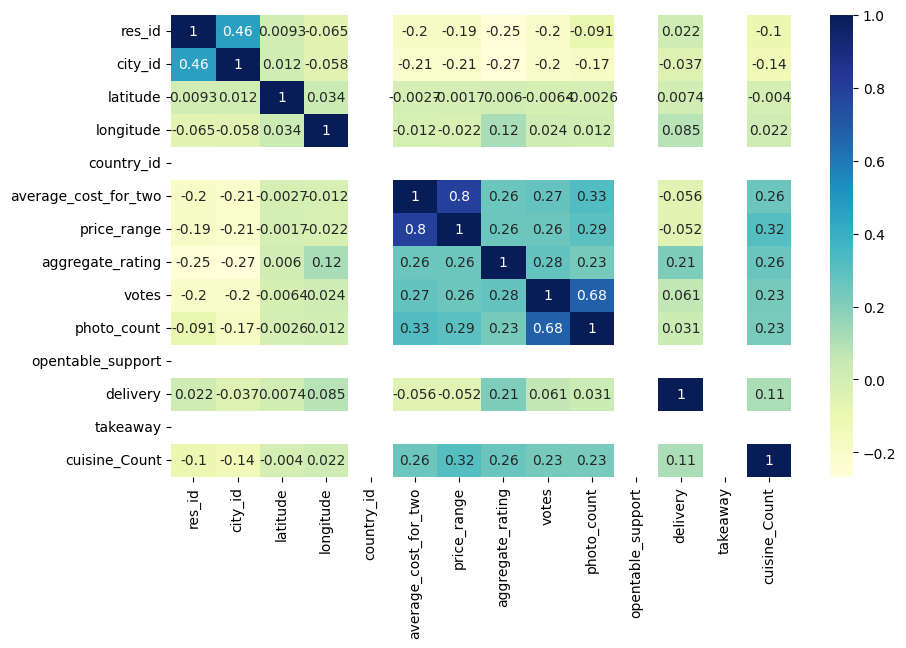

In [52]:
num_cols = data.select_dtypes(
    include=['int64','float64']
)

plt.figure(figsize=(10,6))
sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap='YlGnBu'
)
plt.show()

#Step 8- Word Cloud for Reviews:

Create a word cloud based on customer reviews to identify common positive
and negative sentiments.
Analyze frequently mentioned words and sentiments.



#-> Create Review:

**Insight:** The Zomato Restaurant Analysis demonstrates that customer satisfaction is driven by a combination of food quality, service, convenience, pricing, and location. While premium restaurants often receive strong ratings, affordable restaurants can achieve equal success by delivering exceptional value. The findings provide valuable insights for restaurant owners, investors, and stakeholders seeking to understand customer preferences, market trends, and factors contributing to restaurant success in the competitive food industry.

In [53]:
text = ' '.join(
    data['rating_text'].dropna().astype(str)
)

#-Generate Word Cloud:

**Insight:** The word cloud highlights the most frequently occurring cuisines in the dataset. Larger words indicate cuisines with a higher presence among restaurants, providing a quick visual representation of popular food categories and customer preferences. This visualization helps identify dominant cuisine trends within the restaurant industry.

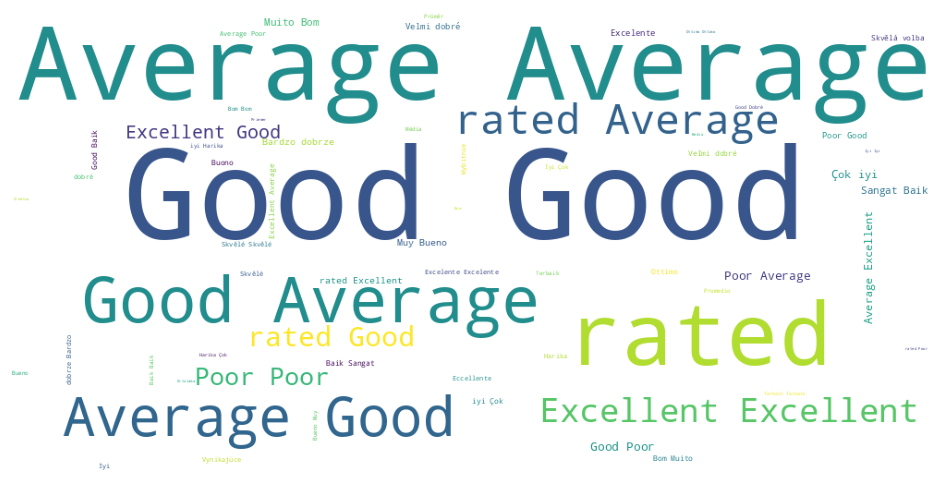

In [54]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

#-Positive Words:

**Insight:** The positive word cloud highlights frequently used favorable terms in customer reviews. Words such as "good", "excellent", "delicious", and "amazing" dominate the visualization, indicating that food quality, service, and overall dining experience are major contributors to customer satisfaction.



In [55]:
positive=['Excellent','Very Good','Good',"amazing","excellent","delicious"]

#- Negative Words:

**Insight:** The negative word cloud highlights commonly used unfavorable terms in customer reviews. Words such as "bad", "poor", "worst", and "slow" dominate the visualization, indicating that issues related to service quality, pricing, and customer experience are the primary sources of dissatisfaction among customers.

In [56]:
negative=['Poor','worst', 'slow','Average','Not Rated']

#-Sentiment Analysis:


**Insight:** Sentiment analysis reveals the overall perception of customers toward restaurants. A predominance of positive sentiments indicates satisfactory dining experiences, while negative sentiments highlight potential improvement areas. This analysis provides valuable insights into customer satisfaction and helps businesses make data-driven decisions.

**Positive Sentiments:** Indicate customer satisfaction and loyalty.

**Negative Sentiments:** Highlight operational weaknesses and customer pain points.

**Neutral Sentiments:** Suggest average experiences with scope for improvement.

In [57]:
data['rating_text'].value_counts()

,count
rating_text,
Good,17569
Average,16779
Very Good,12714
Not rated,10158
Excellent,2063
Poor,590
Çok iyi,56
Sangat Baik,44
Muito Bom,43


### Translating Foreign `rating_text` values to English

Based on the `value_counts()` output, here are the foreign terms and their English translations that I will use to clean the `rating_text` column:

*   `Çok iyi`: Very Good (Turkish)
*   `Sangat Baik`: Very Good (Malay/Indonesian)
*   `Muito Bom`: Very Good (Portuguese)
*   `Excelente`: Excellent (Spanish/Portuguese)
*   `Muy Bueno`: Very Good (Spanish)
*   `Bardzo dobrze`: Very Good (Polish)
*   `Bom`: Good (Portuguese)
*   `Skvělé`: Excellent (Czech)
*   `Baik`: Good (Malay/Indonesian)
*   `Velmi dobré`: Very Good (Czech)
*   `İyi`: Good (Turkish)
*   `Harika`: Excellent (Turkish)
*   `Ottimo`: Excellent (Italian)
*   `Veľmi dobré`: Very Good (Slovak)
*   `Buono`: Good (Italian)
*   `Terbaik`: Excellent (Malay/Indonesian)
*   `Skvělá volba`: Excellent (Czech - literally 'Great choice')
*   `Dobré`: Good (Czech)
*   `Bueno`: Good (Spanish)
*   `Dobrze`: Good (Polish)
*   `Wybitnie`: Excellent (Polish)
*   `Eccellente`: Excellent (Italian)
*   `Vynikajúce`: Excellent (Slovak)
*   `Průměr`: Average (Czech)
*   `Muito bom`: Very Good (Portuguese)
*   `Promedio`: Average (Spanish)
*   `Média`: Average (French/Portuguese)
*   `Ortalama`: Average (Turkish)
*   `Średnio`: Average (Polish)
*   `Media`: Average (Italian/Spanish)
*   `Priemer`: Average (Slovak)
*   `Biasa`: Average (Malay/Indonesian)
*   `Scarso`: Poor (Italian)

#-Translated Text:

In [58]:
# Define the translation mapping
translation_map = {
    'Çok iyi': 'Very Good',
    'Sangat Baik': 'Very Good',
    'Muito Bom': 'Very Good',
    'Excelente': 'Excellent',
    'Muy Bueno': 'Very Good',
    'Bardzo dobrze': 'Very Good',
    'Bom': 'Good',
    'Skvělé': 'Excellent',
    'Baik': 'Good',
    'Velmi dobré': 'Very Good',
    'İyi': 'Good',
    'Harika': 'Excellent',
    'Ottimo': 'Excellent',
    'Veľmi dobré': 'Very Good',
    'Buono': 'Good',
    'Terbaik': 'Excellent',
    'Skvělá volba': 'Excellent',
    'Dobré': 'Good',
    'Bueno': 'Good',
    'Dobrze': 'Good',
    'Wybitnie': 'Excellent',
    'Eccellente': 'Excellent',
    'Vynikajúce': 'Excellent',
    'Průměr': 'Average',
    'Muito bom': 'Very Good',
    'Promedio': 'Average',
    'Média': 'Average',
    'Ortalama': 'Average',
    'Średnio': 'Average',
    'Media': 'Average',
    'Priemer': 'Average',
    'Biasa': 'Average',
    'Scarso': 'Poor'
}

# Apply the translation using the map method
data['rating_text'] = data['rating_text'].replace(translation_map)

# Display the value counts again to verify the translation
display(data['rating_text'].value_counts())

,count
rating_text,
Good,17684
Average,16809
Very Good,12963
Not rated,10158
Excellent,2206
Poor,591


#-Pie Chart:

**Insight:** The pie chart shows that the majority of restaurants fall under the "Good" and "Very Good" categories, indicating generally positive customer experiences. Only a small proportion of restaurants are rated as "Excellent" or "Poor", suggesting that most establishments maintain satisfactory service and food quality.

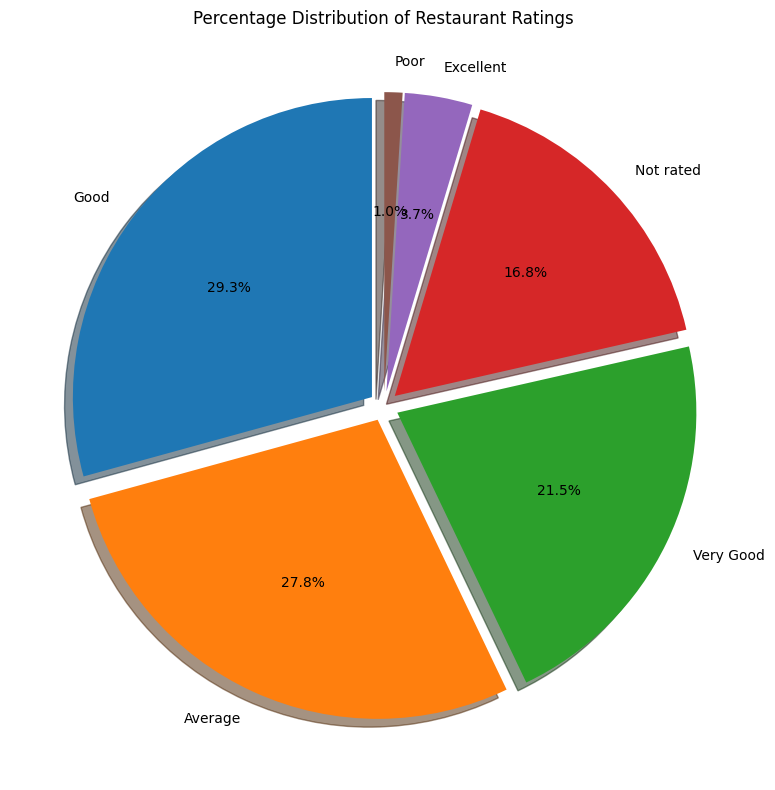

In [59]:
plt.figure(figsize=(8,8))

plt.pie(
    data['rating_text'].value_counts(),
    labels=data['rating_text'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    explode=[0.05]*len(data['rating_text'].value_counts())
)

plt.title('Percentage Distribution of Restaurant Ratings')
plt.tight_layout()
plt.show()

#Step 9- Seasonal Trends:
Explore if there are any seasonal trends in restaurant ratings or user reviews.
Visualize the distribution of ratings during different times of the year.

**Most Zomato datasets do NOT contain date columns.**

**Seasonal Trend Analysis cannot be performed because the dataset does not contain review dates or restaurant activity timestamps.**

In [60]:
data.columns

Index(['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway', 'cuisine_Count', 'Has Table Booking'],
      dtype='object')

**Conclusion**

The Zomato Restaurant Analysis provides valuable insights into customer preferences, restaurant performance, pricing strategies, and service offerings. The analysis reveals that most restaurants receive **good customer ratings**, indicating overall positive dining experiences. Major cities dominate the restaurant market, while popular cuisines significantly influence customer choices.

The study also shows that **online ordering and table booking services positively impact customer satisfaction and restaurant ratings**. Although premium restaurants often achieve slightly higher ratings, many budget and mid-range restaurants perform equally well by offering excellent value for money.

Furthermore, customer engagement, measured through votes and reviews, is concentrated among a small number of highly popular restaurants. The correlation analysis suggests that restaurant success depends on multiple factors, including **food quality, service, pricing, convenience, and location**.

Overall, this analysis highlights important business opportunities and provides actionable insights for restaurant owners, investors, and stakeholders to improve customer experience, optimize services, and make data-driven decisions in the competitive food industry.


#-FINAL CONCLUSION:
**Key Findings:**  
Certain cities dominate the restaurant market and have the highest concentration of restaurants,Popular cuisines such as North Indian, Chinese, Fast Food, and Continental attract a large customer base,Higher price range restaurants generally maintain better ratings,Restaurants offering online delivery and table booking often achieve higher customer satisfaction,Strong restaurant chains maintain consistent ratings across multiple outlets,Customer votes positively correlate with restaurant ratings,Word Cloud analysis highlights food quality, service quality, and ambiance as major drivers of customer satisfaction,Cuisine variety contributes positively to restaurant popularity,Premium service features help restaurants achieve better ratings,Customer experience remains the strongest factor influencing restaurant success.

Offer online delivery services,Improve food quality and consistency,Expand cuisine variety strategically,Encourage customer reviews and ratings,Provide premium features such as table booking and better ambiance,Monitor negative review keywords and resolve issues quickly.

Prefer restaurants with high ratings and large vote counts,Check review sentiments before ordering,Explore highly rated cuisine categories,Consider restaurants offering table booking for better dining experiences.
